# EDA

## LOAD DATA

In [16]:
import duckdb
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

os.chdir("/Users/jakoberhard/Library/CloudStorage/GoogleDrive-jakanterh@gmail.com/My Drive/uni/python/TBA_project")

con = duckdb.connect("data/train.duckdb")

con.execute("""
CREATE OR REPLACE TABLE train_delay AS
            SELECT * FROM
            read_parquet('data/train_delay_cleaned.parquet')
            """)

df_features = con.execute("SELECT * FROM train_delay").fetchdf()

## CHECK CORRECTNESS OF DATASET

In [3]:
df_features.describe()

,ride_id,departure_planned,departure_real,arrival_planned,arrival_real,temperature,precipitation,wind_speed,delay,stops_total,...,arrival_planned_dest,travel_time,weekday,month,hour,dwell_time_planned,stop_index,time_since_start_planned,share_ride_time,delay_cat
count,1.842266e+06,1642112,1642235,1642112,1642230,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,...,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06
mean,1.190158e+05,2025-04-20 00:33:01.594458,2025-04-20 00:38:15.188350,2025-04-20 01:05:16.456526,2025-04-20 01:07:21.069289,1.074211e+01,2.001426e+00,1.603990e+01,9.585715e+00,1.084977e+01,...,1.483871e+01,3.283729e+02,2.953455e+00,7.781153e+00,1.345168e+01,2.369372e+00,5.924884e+00,1.619217e+02,4.928262e-01,2.141873e-02
min,8.300000e+01,2024-07-01 00:01:00,2024-07-01 00:02:00,2024-07-01 00:07:00,2024-07-01 00:09:00,-7.850000e+00,0.000000e+00,2.200000e+00,-5.300000e+01,2.000000e+00,...,0.000000e+00,5.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.556700e+04,2024-11-30 13:58:45,2024-11-30 13:57:30,2024-11-30 14:31:00,2024-11-30 14:29:00,4.890000e+00,0.000000e+00,1.150000e+01,1.000000e+00,8.000000e+00,...,1.100000e+01,2.660000e+02,1.000000e+00,5.000000e+00,9.000000e+00,1.000000e+00,3.000000e+00,4.300000e+01,1.538462e-01,0.000000e+00
50%,1.207845e+05,2025-04-20 08:45:30,2025-04-20 08:40:00,2025-04-20 09:24:00,2025-04-20 09:16:00,1.062000e+01,2.000000e-01,1.530000e+01,3.000000e+00,1.100000e+01,...,1.500000e+01,3.170000e+02,3.000000e+00,8.000000e+00,1.400000e+01,2.000000e+00,5.000000e+00,1.420000e+02,4.864865e-01,0.000000e+00
75%,1.724380e+05,2025-09-18 17:43:15,2025-09-18 17:55:00,2025-09-18 18:23:00,2025-09-18 18:28:00,1.667000e+01,2.100000e+00,1.960000e+01,1.200000e+01,1.300000e+01,...,2.000000e+01,3.850000e+02,5.000000e+00,1.100000e+01,1.800000e+01,3.000000e+00,8.000000e+00,2.550000e+02,8.285714e-01,0.000000e+00
max,2.332690e+05,2025-12-31 23:50:00,2025-12-31 23:50:00,2025-12-31 23:58:00,2025-12-31 23:54:00,3.063000e+01,5.750000e+01,5.900000e+01,4.060000e+02,2.900000e+01,...,2.300000e+01,8.390000e+02,6.000000e+00,1.200000e+01,2.300000e+01,6.900000e+01,2.900000e+01,8.390000e+02,1.000000e+00,2.000000e+00
std,6.540309e+04,NaN,NaN,NaN,NaN,7.173175e+00,3.994898e+00,5.952543e+00,1.640014e+01,4.004719e+00,...,5.974872e+00,1.176464e+02,1.993495e+00,3.401780e+00,5.444643e+00,2.685650e+00,3.882317e+00,1.325944e+02,3.514205e-01,1.589070e-01


### CHECK HIGH-DIMENSIONAL FEATURES

In [ ]:
# train name
result = df_features.groupby("train_name")["ride_id"].nunique()
print(result.describe(), "\n")

# station name
result = df_features.groupby("station_current")["ride_id"].nunique()
print(result.describe())

These features should not be hot-encoded because the number of dimensions would explode then. Simple target encoding does not work because of the time-dependence. Therefore, historical averages are computed per station and train (name).

Station_start and station_dest were also deleted out of this reason.

### CHECK CORRELATIONS

In [ ]:
cols = [
    "temperature", "precipitation_log", "wind_speed",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "travel_time", "stops_total", "dwell_time_planned",
    "stop_index", "time_since_start_planned", "share_ride_time",
    "hist_delay_station_avg", "hist_delay_station_q90", "hist_delay_station_count",
    "hist_delay_train_avg", "hist_delay_train_q90", "hist_delay_train_count",
    "delay"
]

df_corr_matrix = df_features[cols]

# compute correlation matrix
corr_matrix = df_corr_matrix.corr()

# visualize 
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.show()

Decision on features:
- Drop stop_index and share_ride_time, heavily correlated with time_since_start_planned and have lower correlation with target
- Drop historical q90 info: highly correlated with avg and has lower correlation with target
- Drop stops_total: contains basically travel_time

## SETUP FOR PLOTTING

In [4]:
# set design
plt.style.use("ggplot") 
sns.set_theme(style = "whitegrid")

# set target
target = "delay_cat"

## CHECK TARGET

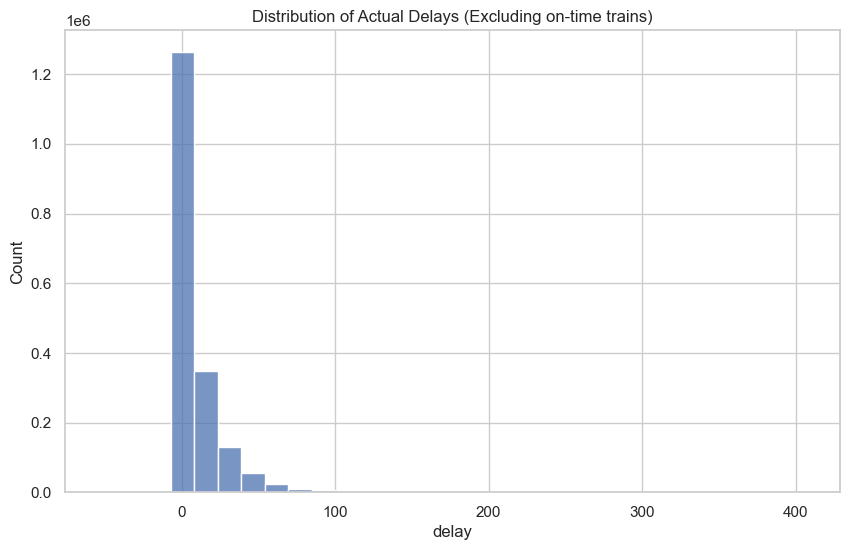

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_features, x = "delay", bins = 30)
plt.title("Distribution of Actual Delays")
plt.show()

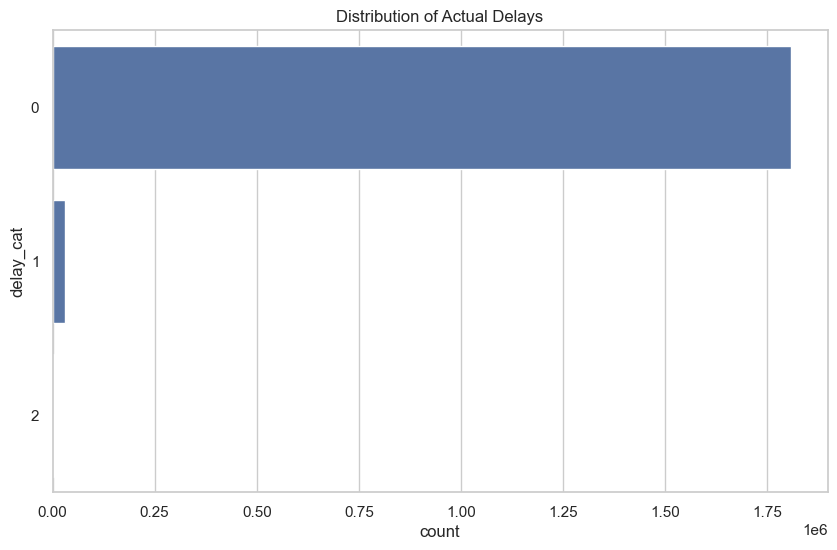

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(data = df_features, y = "delay_cat")
plt.title("Distribution of Actual Delays")
plt.show()

## CONTINOUS

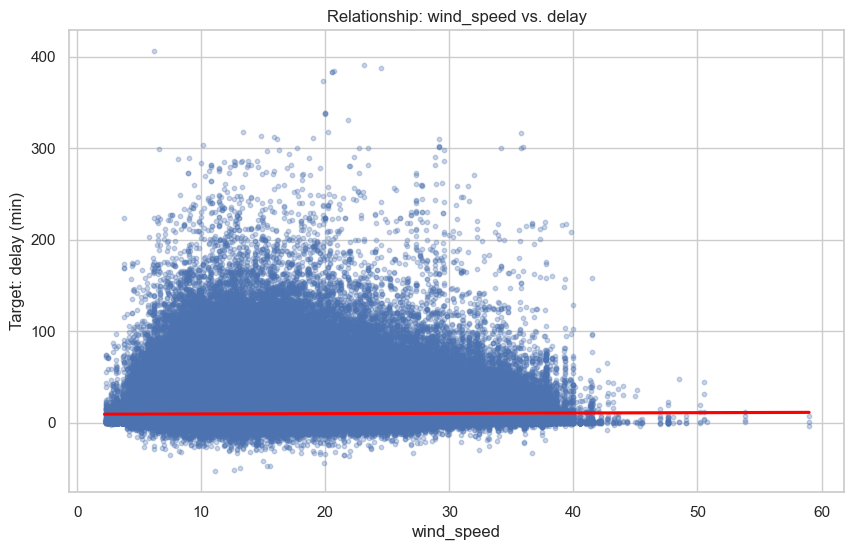

In [ ]:
def plot_cont_vs_cont(df, feature, target):
    plt.figure(figsize=(10, 6))

    sns.regplot(data=df, x=feature, y=target, 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})
    
    plt.title(f'Relationship: {feature} vs. {target}')
    plt.xlabel(feature)
    plt.ylabel(f'Target: {target} (min)')
    plt.show()


plot_cont_vs_cont(df_features, "wind_speed", "delay")




## CATEGORICAL

/var/folders/9n/ws1j083x5m9d1jv6n898lzlw0000gn/T/ipykernel_88809/333047699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y=target, palette="Set2")


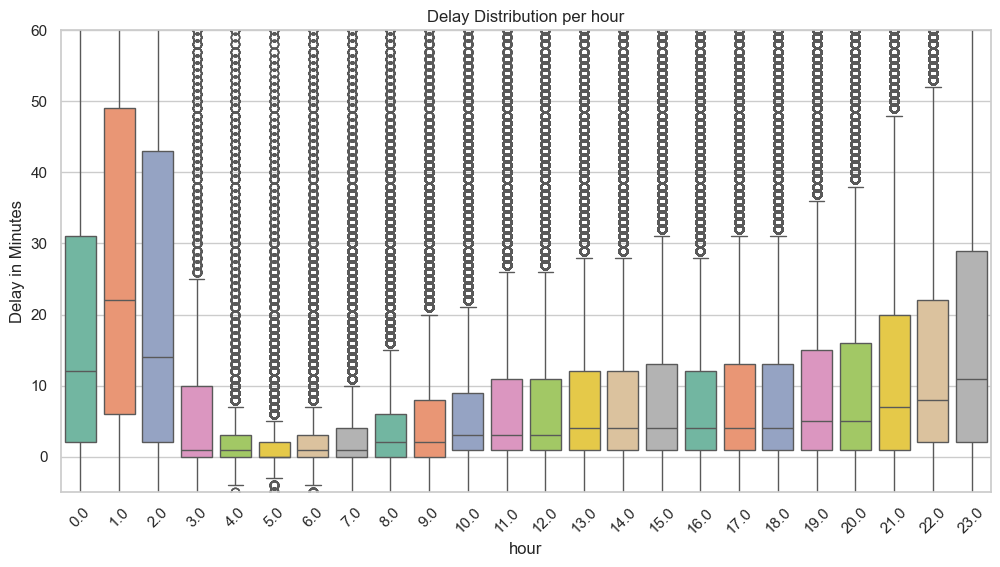

In [25]:
def plot_cat_vs_cont_box(df, feature, target):
    plt.figure(figsize=(12, 6))
    
    # Boxplot zeigt Median, Quartile und Ausreißer
    sns.boxplot(data=df, x=feature, y=target, palette="Set2")
    
    # Da Verspätungen oft Ausreißer haben, begrenzen wir y für die Lesbarkeit
    # Du kannst diesen Teil weglassen, wenn du alle Extreme sehen willst
    plt.ylim(-5, 60) 
    
    plt.title(f'Delay Distribution per {feature}')
    plt.ylabel('Delay in Minutes')
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.show()

plot_cat_vs_cont_box(df_features, 'hour', 'delay')

## CORRELATIONS

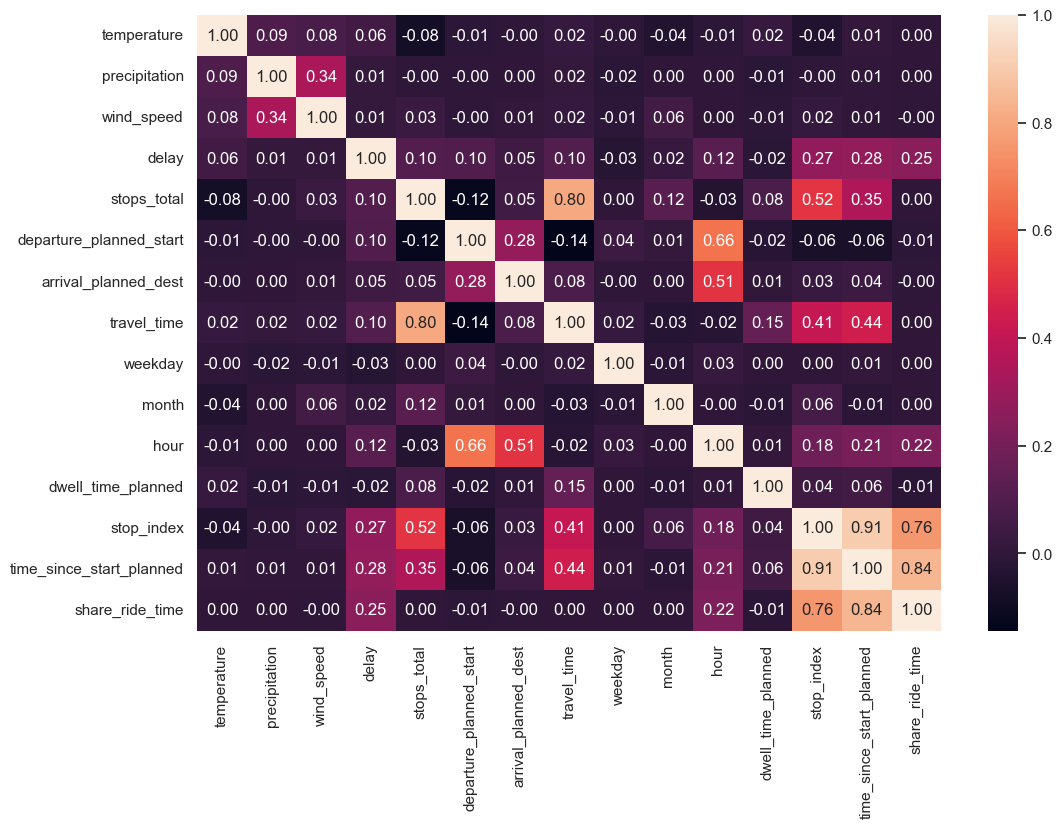

In [33]:
plt.figure(figsize=(12, 8))
# Wir nehmen nur numerische Spalten
numeric_df = df_features.select_dtypes(include=[np.number]).drop(columns = ["ride_id", "delay_cat"])
sns.heatmap(numeric_df.corr(), annot = True, fmt = ".2f")
plt.show()

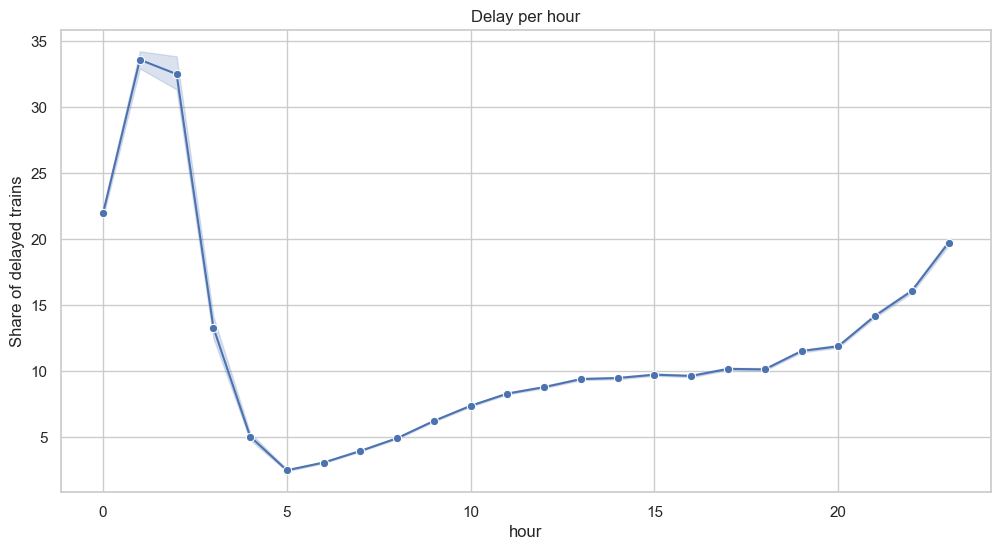

In [50]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_features, x = "hour", y = "delay", marker = "o")
plt.title("Delay per hour")
plt.ylabel("Share of delayed trains")
plt.show()